# Stated or Revealed Risk?
## Reproducible analysis companion

This notebook audits the FAR-Trans sample construction and summarizes the final out-of-time results. Model outputs in `results_final/` are generated by deterministic CatBoost runs with a 2019–2020 train, 2021 validation, and 2022 holdout split.

## tl;dr

- The final sample contains **35,424 customer–security–event exposures**, **5,492 customers**, and **552 extreme negative-return events**.
- Only **7.0%** of exposures led to a trade within five trading days.
- Observed MiFID risk categories are not monotonically ordered by actual response rates and are not statistically significant after behavioral controls.
- On the 2022 holdout, the event-and-position baseline achieved PR-AUC **0.245**; adding prior observed extreme-event response raised it to **0.286**.
- Event-block bootstrap supports the incremental value of prior observed response history, while the customer-profile bundle does not produce stable PR-AUC improvement.

## Context & Methods

The study is predictive and descriptive, not causal. An event is a one-day raw loss of at least 5% whose market-adjusted abnormal return is below the security's rolling prior 1st percentile. Events within 20 trading days for the same security are deduplicated. Responses are Buy, Sell, or NoAction during trading days t+1 through t+5.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
DATA = ROOT / 'data/derived/final_exposure_dataset.csv.gz'
RESULTS = ROOT / 'results_final'
FIGURES = ROOT / 'figures_final'
assert DATA.exists() and RESULTS.exists()


### Key assumptions

- Market return is proxied by the daily cross-sectional median return of eligible XATH stocks.
- Customer–security pairs containing reconstructed negative transaction IDs are excluded.
- Event-day transactions are excluded because timestamps are daily.
- Corporate actions are not exhaustively linked, so the paper uses the neutral term *extreme negative-return event*, not an exogenous shock.

## Data

In [2]:
data = pd.read_csv(DATA, parse_dates=['event_date'])
summary = {
    'exposures': len(data),
    'customers': data.customerID.nunique(),
    'events': (data.event_date.astype(str) + '|' + data.ISIN).nunique(),
    'actions': int(data.acted.sum()),
    'buys': int(data.bought.sum()),
    'sells': int(data.sold.sum()),
}
summary


{'exposures': 35424,
 'customers': 5492,
 'events': 552,
 'actions': 2482,
 'buys': 1420,
 'sells': 1062}

In [3]:
assert summary == {'exposures': 35424, 'customers': 5492, 'events': 552, 'actions': 2482, 'buys': 1420, 'sells': 1062}
data.response.value_counts().to_frame('count')


,count
response,
NoAction,32942
Buy,1420
Sell,1062


## Results

In [4]:
risk = pd.read_csv(RESULTS / 'descriptive_by_risk.csv')
year = pd.read_csv(RESULTS / 'descriptive_by_year.csv')
metrics = pd.read_csv(RESULTS / 'action_model_metrics.csv')
bootstrap = pd.read_csv(RESULTS / 'bootstrap_metric_differences.csv')
display(risk)
display(year)
display(metrics[metrics.model.str.startswith('M')])
display(bootstrap)


,riskLevel,exposures,actions,action_rate,buy_rate,sell_rate,sell_share_among_actors
0,Aggressive,6092,412,0.067630,0.040217,0.027413,0.405340
1,Balanced,16124,1197,0.074237,0.042049,0.032188,0.433584
2,Conservative,1243,63,0.050684,0.025744,0.024940,0.492063
3,Income,11965,810,0.067697,0.038863,0.028834,0.425926


,year,exposures,actions,action_rate,buy_rate,sell_rate
0,2019,390,28,0.071795,0.043590,0.028205
1,2020,9745,946,0.097075,0.063007,0.034069
2,2021,7997,753,0.094160,0.042766,0.051394
3,2022,17292,755,0.043662,0.025850,0.017812


,model,n_train,n_val,n_test,test_prevalence,PR_AUC,ROC_AUC,Brier,LogLoss,best_iteration
0,M0_event_position,10135,7997,17292,0.043662,0.244830,0.825620,0.037520,0.151263,178
1,M1_plus_profile,10135,7997,17292,0.043662,0.242825,0.828440,0.037470,0.150984,123
2,M2_plus_behavior,10135,7997,17292,0.043662,0.253153,0.831257,0.036963,0.145945,382
3,M3_profile_behavior,10135,7997,17292,0.043662,0.256301,0.825781,0.036871,0.146431,380
4,M4_plus_prior_shocks,10135,7997,17292,0.043662,0.286209,0.839776,0.036253,0.142066,131


,comparison,metric,mean_diff,ci_low,ci_high,bootstrap_draws
0,M1_plus_profile minus M0_event_position,PR_diff,-0.002339,-0.019241,0.012902,300
1,M1_plus_profile minus M0_event_position,Brier_diff,-0.000054,-0.000312,0.000170,300
2,M1_plus_profile minus M0_event_position,AUC_diff,0.002990,-0.003799,0.009876,300
3,M4_plus_prior_shocks minus M3_profile_behavior,PR_diff,0.030835,0.013947,0.048154,300
4,M4_plus_prior_shocks minus M3_profile_behavior,Brier_diff,-0.000624,-0.000931,-0.000341,300
5,M4_plus_prior_shocks minus M3_profile_behavior,AUC_diff,0.014363,0.004652,0.024420,300
6,R1_risk_only minus M0_event_position,PR_diff,-0.001130,-0.016520,0.013925,300
7,R1_risk_only minus M0_event_position,Brier_diff,-0.000085,-0.000290,0.000164,300
8,R1_risk_only minus M0_event_position,AUC_diff,0.001384,-0.003864,0.005709,300
9,R2_behavior_plus_risk minus M2_plus_behavior,PR_diff,0.011559,0.000612,0.023484,300


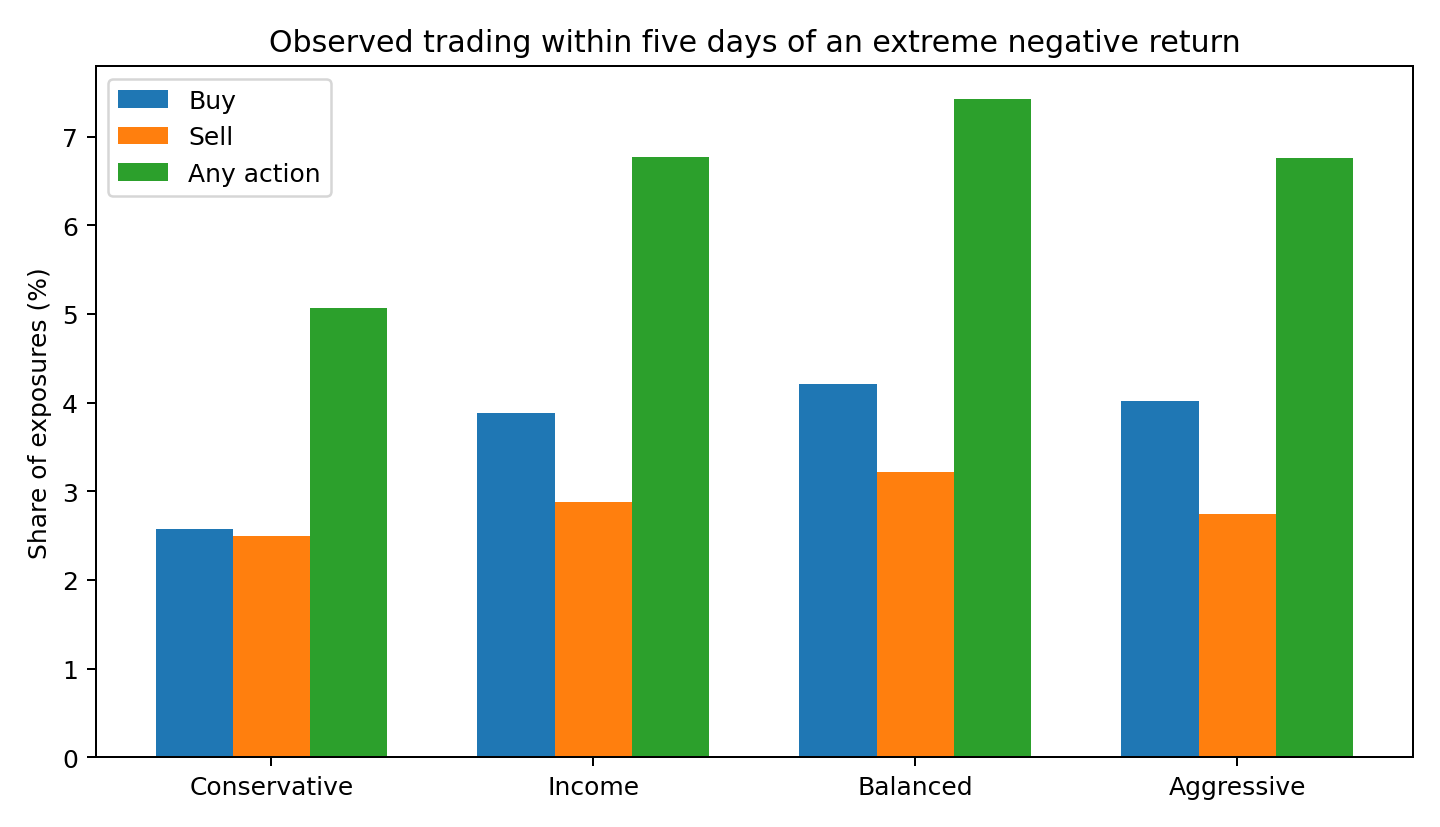

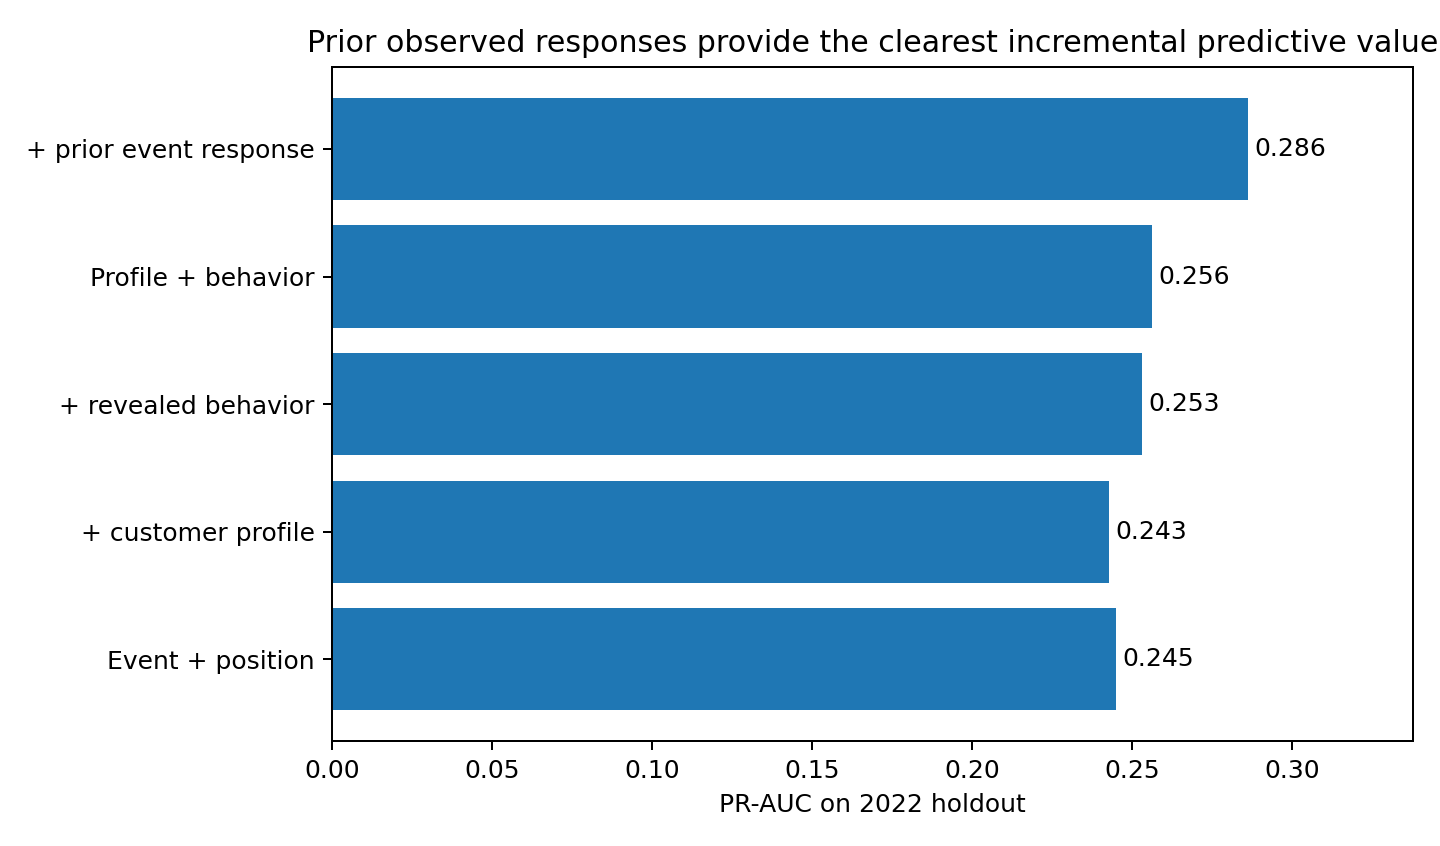

In [5]:
display(Image(filename=str(FIGURES / 'fig2_response_by_risk.png')))
display(Image(filename=str(FIGURES / 'fig4_action_model_performance.png')))


## Takeaways

1. **Stated risk is not a simple behavioral ranking.** Balanced customers had the highest five-day action rate; Aggressive customers did not.
2. **The main predictive result is behavioral persistence.** The full model's 2022 PR-AUC is about 0.286 versus 0.245 for the event-and-position baseline.
3. **The MiFID profile result is deliberately conservative.** Its ranking gain is weak and unstable after event-block resampling; observed behavior contributes more consistently.
4. **The year split matters.** The 2022 action prevalence is 4.37%, substantially below 2020–2021, making random train/test splitting inappropriate.
5. **Publication claims must remain non-causal.** The data support prediction and profile–behavior comparison, not the causal effect of price shocks or suitability questionnaires.